In [1]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict, Annotated
# 동적으로 Node를 만들 수 있고, 여러 Node를 병렬로 실행 가능하게 해줌.
from langgraph.types import Send 
import operator

In [2]:
from typing import Union

class State(TypedDict):
    words: list[str]
    # Union[A, B]: A 또는 B 타입으로 정해짐
    output: Annotated[list[dict[str, Union[str, int]]], operator.add]

graph_builder = StateGraph(State)

In [3]:
def node_one(state: State):    
    print(f"I want to count {len(state["words"])} words in my state.")
    return {}

def node_two(word: str):
    return {
        "output": [
            {
                "word": word,
                "lettwrs": len(word),
            }
        ]
    }

In [4]:
graph_builder.add_node("node_one", node_one)
graph_builder.add_node("node_two", node_two)

def dispatcher(state: State):
    # words = state["words"]
    # sends = []
    # for word in words:
    #     sends.append(Send("node_two", word))
    # return sends
    return [Send("node_two", word) for word in state["words"]]

graph_builder.add_edge(START, "node_one")
graph_builder.add_conditional_edges("node_one", dispatcher, ["node_two"])
graph_builder.add_edge("node_two", END)

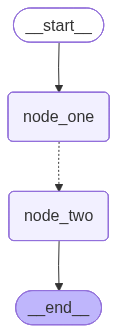

In [5]:
graph = graph_builder.compile()

graph

In [6]:
graph.invoke({
    "words": ["hello", "world", "how", "are", "you", "doing"],
})

I want to count 6 words in my state.


{'words': ['hello', 'world', 'how', 'are', 'you', 'doing'],
 'output': [{'word': 'hello', 'lettwrs': 5},
  {'word': 'world', 'lettwrs': 5},
  {'word': 'how', 'lettwrs': 3},
  {'word': 'are', 'lettwrs': 3},
  {'word': 'you', 'lettwrs': 3},
  {'word': 'doing', 'lettwrs': 5}]}